In [20]:
import numpy as np

np.float = float
from skmultiflow.drift_detection.adwin import ADWIN
import random
import pandas as pd

import torch

from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix

from sklearn.preprocessing import LabelEncoder

In [23]:
# loading the data
reviews = pd.read_json("experiment_1/CDs_and_Vinyl.jsonl", lines=True)

In [24]:
# preparing the data
reviews = reviews[reviews["rating"] != 3]
reviews = reviews[reviews["timestamp"] > "2015-01-01"]
reviews["year"] = reviews["timestamp"].apply(lambda x: x.year)
reviews["month"] = reviews["timestamp"].apply(lambda x: x.month)
reviews["day"] = reviews["timestamp"].apply(lambda x: x.day)

In [25]:
# create reference dataframe
reference_data = reviews[reviews["timestamp"] > "2015-01-01"]
reference_data = reference_data[reference_data["timestamp"] < "2019-01-01"]
# create evaluation dataframe
evaluation_data = reviews[reviews["timestamp"] >= "2019-01-01"]
evaluation_data = evaluation_data.set_index(evaluation_data["timestamp"])
evaluation_data.sort_index(inplace=True)

In [26]:
# remove products that appear after ref
evaluation_data_with_old_products = evaluation_data[
    evaluation_data["parent_asin"].isin(reference_data["parent_asin"])
]

In [27]:
# encode features in the reviews for use in ml model
sparse_features = ["parent_asin", "user_id", "year", "month", "day"]
for feat in sparse_features:
    lbe = LabelEncoder()
    reviews[feat] = lbe.fit_transform(reviews[feat])

In [28]:
def create_matrix(df):
    N = len(df["user_id"].unique())
    M = len(df["product_id"].unique())

    # Map Ids to indices
    user_mapper = dict(zip(np.unique(df["user_id"]), list(range(N))))
    product_mapper = dict(zip(np.unique(df["product_id"]), list(range(M))))

    # Map indices to IDs
    user_inv_mapper = dict(zip(list(range(N)), np.unique(df["user_id"])))
    product_inv_mapper = dict(zip(list(range(M)), np.unique(df["product_id"])))

    user_index = [user_mapper[i] for i in df["user_id"]]
    product_index = [product_mapper[i] for i in df["product_id"]]

    X = csr_matrix((df["rating"], (product_index, user_index)), shape=(M, N))

    return X, user_mapper, product_mapper, user_inv_mapper, product_inv_mapper

In [29]:
# rename for use in function
reference_data["product_id"] = reference_data["parent_asin"]

In [30]:
X, user_mapper, product_mapper, user_inv_mapper, product_inv_mapper = create_matrix(
    reference_data
)

In [31]:
# train ml model
kNN = NearestNeighbors(n_neighbors=5, algorithm="brute", metric="cosine")
kNN.fit(X)

NearestNeighbors(algorithm='brute', metric='cosine')

In [32]:
def find_similar_products(product_id, X, k, metric="cosine", show_distance=False):
    neighbour_ids = []

    product_ind = product_mapper[product_id]
    product_vec = X[product_ind]
    k += 1
    product_vec = product_vec.reshape(1, -1)
    neighbour = kNN.kneighbors(product_vec, return_distance=show_distance)
    for i in range(0, k):
        n = neighbour.item(i)
        neighbour_ids.append(product_inv_mapper[n])
    neighbour_ids.pop(0)
    return neighbour_ids

In [75]:
# sample reviews from products
sampled = evaluation_data_with_old_products.sample(10000)

In [89]:
# save sample
sampled.reset_index(inplace=True, drop=True)
sampled.to_json("sampled_products.json")

In [83]:
# store the predictions of the recommendation system (takes a long time)
preds = []
for i in range(len(sampled)):
    preds.append(find_similar_products(sampled["parent_asin"].values[i], X, 4))

In [76]:
sampled.sort_index(inplace=True)

In [85]:
# store the recommendations in dataframe
sampled["recommendation"] = preds

In [94]:
reviews_copy = pd.read_json("experiment_1/CDs_and_Vinyl.jsonl", lines=True)

In [97]:
# ensure same strutcture as ctr-predictor training data
reviews_copy = reviews_copy[reviews_copy["rating"] != 3]
reviews_copy = reviews_copy[reviews_copy["timestamp"] > "2015-01-01"]

In [102]:
# create a mapper for the ctr-predictor
music_mapper = dict(
    zip(reviews_copy["parent_asin"].unique(), reviews["parent_asin"].unique())
)

In [109]:
# create a mapper for the ctr-predictor
music_user_mapper = dict(
    zip(reviews_copy["user_id"].unique(), reviews["user_id"].unique())
)

In [114]:
# load the ctr-predictor
model = torch.load("./model_formatted_music_v2")

In [118]:
# calculate click-through-rate for the recommendations
def mean_predicted_ctr():
    res = []
    for i in range(len(sampled)):
        temp = []
        for j in range(len(sampled["recommendation"][i])):
            temp.append(
                model.predict(
                    {
                        "parent_asin": pd.Series(
                            music_mapper[sampled["recommendation"][i][j]]
                        ),
                        "user_id": pd.Series(music_user_mapper[sampled["user_id"][i]]),
                        "year": pd.Series(sampled["year"][i] - 2015),
                        "month": pd.Series(sampled["month"][i] - 1),
                        "day": pd.Series(sampled["day"][i] - 1),
                    }
                )
            )
        res.append(temp)
    return res

In [119]:
ctr_list = mean_predicted_ctr()

In [120]:
ctr_list

[[array([[0.99991059]]),
  array([[0.99997616]]),
  array([[0.99995983]]),
  array([[0.99996758]])],
 [array([[0.99994981]]),
  array([[0.99907351]]),
  array([[0.99925488]]),
  array([[0.99858344]])],
 [array([[0.99998438]]),
  array([[0.99999118]]),
  array([[0.99998558]]),
  array([[0.99998569]])],
 [array([[0.01773577]]),
  array([[0.01396407]]),
  array([[0.89759821]]),
  array([[0.00295065]])],
 [array([[0.99995291]]),
  array([[0.99998188]]),
  array([[0.99990892]]),
  array([[0.99968171]])],
 [array([[0.99957412]]),
  array([[0.99998784]]),
  array([[0.99998832]]),
  array([[0.99891591]])],
 [array([[0.99999952]]),
  array([[0.99968016]]),
  array([[0.99989021]]),
  array([[0.9998678]])],
 [array([[0.99980623]]),
  array([[0.99971431]]),
  array([[0.99992096]]),
  array([[0.99999833]])],
 [array([[0.9803099]]),
  array([[0.85741419]]),
  array([[0.03047163]]),
  array([[0.79211545]])],
 [array([[0.97392875]]),
  array([[0.54375345]]),
  array([[0.54407793]]),
  array([[0.543753

In [121]:
means = []
for i in range(len(ctr_list)):
    means.append(np.mean(ctr_list[i]))

[0.9999535381793976,
 0.9992154091596603,
 0.9999867081642151,
 0.23306217446224764,
 0.9998813569545746,
 0.9996165484189987,
 0.9998594224452972,
 0.9998599588871002,
 0.6650777934119105,
 0.6513783931732178,
 0.999998152256012,
 0.9995860904455185,
 0.9992972612380981,
 0.9275415539741516,
 0.998763307929039,
 0.9996485561132431,
 0.9956416636705399,
 0.9966843128204346,
 0.9998223632574081,
 0.9999983906745911,
 0.47573903226293623,
 0.7104234993457794,
 0.729720720089972,
 0.9996227324008942,
 0.9999025613069534,
 0.9987823963165283,
 0.9999932050704956,
 0.999992698431015,
 0.7965951226651669,
 0.7517002522945404,
 0.9995349496603012,
 0.9992405027151108,
 0.9999755918979645,
 0.9995008260011673,
 0.6160915791988373,
 0.9999552071094513,
 0.9999142736196518,
 0.9998732805252075,
 0.9998960345983505,
 0.9990556836128235,
 0.9711687713861465,
 0.9998067319393158,
 0.7505261257756501,
 0.9998864829540253,
 0.7969423681497574,
 0.9997523576021194,
 0.01453598728403449,
 0.99756287038

In [122]:
np.mean(means)

0.8422354594649202

In [124]:
series_means = pd.Series(means, index=sampled["timestamp"])

In [127]:
rolling_means = series_means.rolling("30D").mean()

<Axes: xlabel='timestamp'>

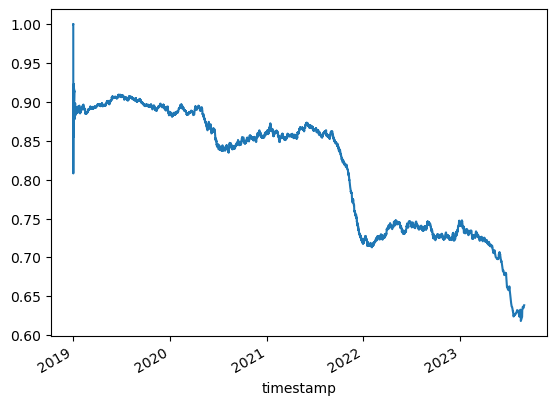

In [130]:
rolling_means.plot()

In [160]:
# create labels for the drift-detectors
correct_recommendations = []
for i in range(len(ctr_list)):
    for j in range(4):
        correct_recommendations.append(
            random.choices(
                [0, 1], weights=[1 - ctr_list[i][j][0][0], ctr_list[i][j][0][0]]
            )[0]
        )

In [179]:
from skmultiflow.drift_detection import DDM
from skmultiflow.drift_detection import EDDM

In [ ]:
# testing the different erb-detectors

In [165]:
adwin = ADWIN()
entry_number = 0
entries = []
for i in range(len(correct_recommendations)):
    adwin.add_element(correct_recommendations[i])
    if adwin.detected_change():
        print(
            "Change detected in data: "
            + str(correct_recommendations[i])
            + " - at index: "
            + str(i)
            + " - at entry: "
            + str(entry_number)
        )
        entries.append(entry_number)
    if i % 4 == 3:
        entry_number = entry_number + 1

Change detected in data: 0 - at index: 19103 - at entry: 4775
Change detected in data: 0 - at index: 19423 - at entry: 4855
Change detected in data: 1 - at index: 19807 - at entry: 4951
Change detected in data: 0 - at index: 21535 - at entry: 5383
Change detected in data: 0 - at index: 24095 - at entry: 6023
Change detected in data: 1 - at index: 26623 - at entry: 6655
Change detected in data: 1 - at index: 28671 - at entry: 7167
Change detected in data: 1 - at index: 30431 - at entry: 7607
Change detected in data: 1 - at index: 31615 - at entry: 7903
Change detected in data: 1 - at index: 32255 - at entry: 8063
Change detected in data: 0 - at index: 32511 - at entry: 8127
Change detected in data: 1 - at index: 32767 - at entry: 8191
Change detected in data: 1 - at index: 33375 - at entry: 8343
Change detected in data: 0 - at index: 33599 - at entry: 8399


In [166]:
for i in entries:
    print(sampled["timestamp"][i])

2020-06-05 03:02:33.642000
2020-06-20 01:00:58.523000
2020-07-09 21:44:26.716000
2020-09-30 15:31:59.734000
2021-01-22 22:17:28.259000
2021-04-16 12:29:11.322000
2021-06-28 16:59:58.220000
2021-09-15 11:56:40.572000
2021-11-27 06:30:09.520000
2021-12-29 17:08:37.270000
2022-01-08 03:23:54.609000
2022-01-20 21:39:06.125000
2022-02-25 17:51:22.584000
2022-03-11 02:48:48.517000


In [174]:
np.datetime64("2019-06-01") + 296 * np.timedelta64(1, "D")

numpy.datetime64('2020-03-23')

In [177]:
np.datetime64("2020-07-07") - np.datetime64("2020-03-23")

numpy.timedelta64(74,'D')

In [190]:
ddm = DDM(min_num_instances=30)
alerts_ddm = []
entry_number = 0
entries = []
for i in range(len(correct_recommendations)):
    ddm.add_element(1 - correct_recommendations[i])
    # if ddm.detected_warning_zone():
    # print('Warning zone has been detected in data: ' + str(correct_recommendations[i]) + ' - of index: ' + str(i) + ' - at entry: '+ str(entry_number))
    if ddm.detected_change():
        print(
            "Change has been detected in data: "
            + str(correct_recommendations[i])
            + " - of index: "
            + str(i)
            + " - at entry: "
            + str(entry_number)
        )
        entries.append(entry_number)
    if i % 4 == 3:
        entry_number = entry_number + 1

Change has been detected in data: 0 - of index: 39 - at entry: 9
Change has been detected in data: 0 - of index: 80 - at entry: 20
Change has been detected in data: 0 - of index: 2238 - at entry: 559
Change has been detected in data: 0 - of index: 2383 - at entry: 595
Change has been detected in data: 0 - of index: 2449 - at entry: 612
Change has been detected in data: 0 - of index: 2498 - at entry: 624
Change has been detected in data: 0 - of index: 2545 - at entry: 636
Change has been detected in data: 0 - of index: 2702 - at entry: 675
Change has been detected in data: 0 - of index: 2733 - at entry: 683
Change has been detected in data: 0 - of index: 2921 - at entry: 730
Change has been detected in data: 0 - of index: 4694 - at entry: 1173
Change has been detected in data: 0 - of index: 4756 - at entry: 1189
Change has been detected in data: 0 - of index: 4809 - at entry: 1202
Change has been detected in data: 0 - of index: 8800 - at entry: 2200
Change has been detected in data: 0 -

In [184]:
for i in entries:
    print(sampled["timestamp"][i])

2019-01-01 16:29:34.472000
2019-01-02 23:24:32.088000
2019-02-16 20:34:01.387000
2019-02-21 05:36:22.877000
2019-02-22 20:43:44.204000
2019-02-24 08:44:13.214000
2019-02-25 12:50:19.513000
2019-02-28 20:37:39.425000
2019-03-01 20:09:17.381000
2019-03-06 19:43:57.636000
2019-04-22 00:08:17.412000
2019-04-24 01:30:16.617000
2019-04-25 15:48:14.962000
2019-07-22 03:57:54.364000
2020-07-07 11:23:40.652000
2021-02-15 19:59:25.556000
2021-02-17 04:53:23.174000
2021-03-02 20:54:06.471000
2021-03-04 22:01:35.772000
2021-03-05 15:36:27.029000
2021-03-07 04:13:25.342000
2021-03-11 11:54:35.926000
2021-03-14 05:59:26.855000
2021-03-15 22:20:37.921000
2021-03-21 22:09:55.868000
2021-03-24 21:58:27.944000
2021-11-24 23:00:07.283000


In [191]:
np.datetime64("2020-07-07") - np.datetime64("2020-03-23")

numpy.timedelta64(106,'D')

In [192]:
ddm = EDDM()
alerts_ddm = []
entry_number = 0
entries = []
for i in range(len(correct_recommendations)):
    ddm.add_element(1 - correct_recommendations[i])
    # if ddm.detected_warning_zone():
    # print('Warning zone has been detected in data: ' + str(correct_recommendations[i]) + ' - of index: ' + str(i) + ' - at entry: '+ str(entry_number))
    if ddm.detected_change():
        print(
            "Change has been detected in data: "
            + str(correct_recommendations[i])
            + " - of index: "
            + str(i)
            + " - at entry: "
            + str(entry_number)
        )
        entries.append(entry_number)
    if i % 4 == 3:
        entry_number = entry_number + 1

Change has been detected in data: 0 - of index: 293 - at entry: 73
Change has been detected in data: 0 - of index: 563 - at entry: 140
Change has been detected in data: 0 - of index: 935 - at entry: 233
Change has been detected in data: 0 - of index: 1260 - at entry: 315
Change has been detected in data: 0 - of index: 1512 - at entry: 378
Change has been detected in data: 0 - of index: 1903 - at entry: 475
Change has been detected in data: 0 - of index: 2136 - at entry: 534
Change has been detected in data: 0 - of index: 14833 - at entry: 3708
Change has been detected in data: 0 - of index: 15057 - at entry: 3764
Change has been detected in data: 0 - of index: 15436 - at entry: 3859
Change has been detected in data: 0 - of index: 15727 - at entry: 3931
Change has been detected in data: 0 - of index: 16140 - at entry: 4035
Change has been detected in data: 0 - of index: 16510 - at entry: 4127
Change has been detected in data: 0 - of index: 16842 - at entry: 4210
Change has been detected

In [196]:
counter = 0
for i in entries:
    print(sampled["timestamp"][i])
    if np.datetime64(sampled["timestamp"][i]) >= np.datetime64("2020-03-23"):
        counter = counter + 1

2019-01-05 22:16:42.335000
2019-01-10 02:57:35.501000
2019-01-16 12:27:51.003000
2019-01-22 19:23:41.742000
2019-01-27 16:55:13.177000
2019-02-06 12:37:59.289000
2019-02-14 01:27:04.362000
2020-01-04 05:00:06.095000
2020-01-08 11:43:53.385000
2020-01-14 23:39:49.010000
2020-01-20 21:54:40.614000
2020-01-29 22:46:05.548000
2020-02-05 20:07:33.553000
2020-02-14 03:28:08.080000
2020-02-21 22:35:12.111000
2020-02-27 22:48:53.450000
2020-03-06 20:42:05.713000
2020-03-14 12:52:05.688000
2020-03-31 12:24:42.115000
2020-04-22 15:44:03.640000
2020-05-05 10:14:38.196000
2020-05-15 17:43:40.626000
2020-05-29 20:03:12.920000
2020-06-05 22:28:57.875000
2020-06-18 19:53:41.748000
2020-06-25 06:38:35.294000
2020-07-05 10:09:31.045000
2020-07-14 18:42:16.537000
2020-07-23 02:53:25.868000
2020-08-02 18:39:18.529000
2020-08-17 20:57:17.763000
2020-08-23 15:07:24.702000
2020-09-07 15:22:29.895000
2020-09-17 19:37:18.114000
2020-09-30 15:31:59.734000
2020-10-08 01:55:32.756000
2020-10-20 16:15:34.863000
2

In [197]:
counter

97